# IBL Brain Wide Map: Single-cell Choice Modulation, Decoding, and Manifold Analysis

This Colab notebook uses the current DANDI NWB layout for the IBL Brain Wide Map dandiset (`000409`) and runs three small analyses on one processed session file - to mimic the results of Brain wide map paper:

1. **Single-cell analysis**: choice modulation of each unit before movement onset.
2. **Decoding**: logistic-regression decoding of wheel choice from spike counts.
3. **Manifold analysis**: PCA trajectories of population activity split by choice.

By default, this notebook uses the **full available task-trial set for one session** after basic eligibility filtering, and all good units from one probe. For fair choice comparisons, the default trial set is the largest balanced set of clockwise and counter-clockwise movement trials.

The notebook reads from the processed NWB file only. It does not download the large raw AP/LF electrophysiology arrays.

In [ ]:
# Install the environment.
import logging
import subprocess
import sys

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

packages = [
    'dandi==0.75.1',
    'remfile==0.1.13',
    'h5py==3.16.0',
    'pynwb==3.1.3',
    'numpy==2.0.2',
    'pandas==2.2.2',
    'matplotlib==3.10.0',
    'scipy==1.16.3',
    'scikit-learn==1.5.2',
]
logging.info('Installing notebook dependencies...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
logging.info('Finished installing dependencies.')


## Imports and configuration

The notebook runs the full educational analysis by default: all eligible movement-choice trials from one session, all good units from the selected probe, and `1000` shuffles for the single-cell modulation test.


In [ ]:
from __future__ import annotations

import atexit
import logging
import os
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import remfile
from dandi.dandiapi import DandiAPIClient
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', force=True)

DANDISET_ID = '000409'
DANDISET_VERSION = os.environ.get('BWM_DANDISET_VERSION', '0.260309.1324')

# We are taking data from one session
ASSET_PATH = (
    'sub-KS091/'
    'sub-KS091_ses-78b4fff5-c5ec-44d9-b5f9-d59493063f00_desc-processed_behavior+ecephys.nwb'
)

# Number of shuffles to do for calculating the p-values
N_SHUFFLES = 1000

PROBE_NAME = os.environ.get('BWM_PROBE_NAME', '') or None
BALANCE_CHOICES = True
COUNT_WINDOW = (-0.15, 0.0)       # seconds before movement onset
PSTH_WINDOW = (-0.30, 0.05)       # seconds around movement onset
PSTH_BIN_SIZE = 0.02
RANDOM_SEED = 0

DEFAULT_OUTPUT_DIR = '/content/bwm_colab_outputs' if Path('/content').exists() else 'bwm_colab_outputs'
OUTPUT_DIR = Path(DEFAULT_OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logging.info('DANDI version: %s', DANDISET_VERSION)
logging.info('Asset path: %s', ASSET_PATH)
logging.info('Output directory: %s', OUTPUT_DIR.resolve())

INFO: DANDI version: 0.260309.1324
INFO: Asset path: sub-KS091/sub-KS091_ses-78b4fff5-c5ec-44d9-b5f9-d59493063f00_desc-processed_behavior+ecephys.nwb
INFO: Output directory: /content/bwm_colab_outputs


## Helper functions

These functions read only compact metadata tables and selected spike-time slices from the processed NWB file.

In [ ]:
@dataclass(frozen=True)
class AnalysisConfig:
    """Configuration values for one notebook run."""

    dandiset_id: str
    dandiset_version: str
    asset_path: str
    probe_name: str | None
    n_shuffles: int
    balance_choices: bool
    count_window: tuple[float, float]
    psth_window: tuple[float, float]
    psth_bin_size: float
    random_seed: int
    output_dir: Path


@dataclass
class SelectedUnit:
    """A compact unit record with only the fields needed for this analysis."""

    row_index: int
    unit_name: str
    probe_name: str
    quality_score: float
    firing_rate: float
    spike_start: int
    spike_stop: int


@dataclass
class AnalysisData:
    """Selected trials, units, and spike arrays used by all analyses."""

    trials: pd.DataFrame
    units: list[SelectedUnit]
    spike_times_by_unit: list[np.ndarray]
    events: np.ndarray
    choice: np.ndarray


CONFIG = AnalysisConfig(
    dandiset_id=DANDISET_ID,
    dandiset_version=DANDISET_VERSION,
    asset_path=ASSET_PATH,
    probe_name=PROBE_NAME,
    n_shuffles=N_SHUFFLES,
    balance_choices=BALANCE_CHOICES,
    count_window=COUNT_WINDOW,
    psth_window=PSTH_WINDOW,
    psth_bin_size=PSTH_BIN_SIZE,
    random_seed=RANDOM_SEED,
    output_dir=OUTPUT_DIR,
)


def decode_if_bytes(value: Any) -> Any:
    """Decode byte strings returned by h5py while leaving other values untouched."""

    if isinstance(value, bytes):
        return value.decode('utf-8')
    return value


def read_dataset(group: h5py.Group, name: str, default: Any = None) -> Any:
    """Read a named HDF5 dataset if present and normalize byte-string arrays."""

    if name not in group:
        return default
    value = group[name][()]
    if isinstance(value, np.ndarray) and value.dtype.kind in {'S', 'O'}:
        return np.array([decode_if_bytes(item) for item in value])
    return decode_if_bytes(value)


def get_processed_asset(config: AnalysisConfig):
    """Fetch the configured processed NWB asset from DANDI."""

    logging.info('Opening DANDI:%s/%s', config.dandiset_id, config.dandiset_version)
    client = DandiAPIClient()
    dandiset = client.get_dandiset(config.dandiset_id, config.dandiset_version)
    asset = dandiset.get_asset_by_path(config.asset_path)
    logging.info('Using processed asset: %s', asset.path)
    return client, asset


def open_h5_file(config: AnalysisConfig):
    """Open the configured remote DANDI NWB file with h5py."""

    client, asset = get_processed_asset(config)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)
    remote_file = remfile.File(s3_url)
    h5_file = h5py.File(remote_file, mode='r')
    return client, remote_file, h5_file


def close_h5_handles() -> None:
    """Close remote/local file handles at the end of the notebook run."""

    for handle_name in ['H5_FILE', 'REMOTE_FILE', 'DANDI_CLIENT']:
        handle = globals().get(handle_name)
        if handle is not None and hasattr(handle, 'close'):
            try:
                handle.close()
            except Exception as exc:
                logging.warning('Could not close %s cleanly: %s', handle_name, exc)


atexit.register(close_h5_handles)

<function __main__.close_h5_handles() -> 'None'>

## Open the processed NWB session file

The notebook defaults to one processed BWM session. If the session has multiple probes, the analysis automatically chooses the probe with the most good units unless `BWM_PROBE_NAME` is set.

In [ ]:
DANDI_CLIENT, REMOTE_FILE, H5_FILE = open_h5_file(CONFIG)

session_id = decode_if_bytes(H5_FILE['/general/session_id'][()]) if '/general/session_id' in H5_FILE else 'unknown'
subject_id = decode_if_bytes(H5_FILE['/general/subject/subject_id'][()]) if '/general/subject/subject_id' in H5_FILE else 'unknown'
logging.info('Loaded subject=%s session_id=%s', subject_id, session_id)
logging.info('Top-level NWB groups: %s', list(H5_FILE.keys()))

INFO: Opening DANDI:000409/0.260309.1324
INFO: Using processed asset: sub-KS091/sub-KS091_ses-78b4fff5-c5ec-44d9-b5f9-d59493063f00_desc-processed_behavior+ecephys.nwb
INFO: Loaded subject=KS091 session_id=78b4fff5-c5ec-44d9-b5f9-d59493063f00
INFO: Top-level NWB groups: ['acquisition', 'analysis', 'file_create_date', 'general', 'identifier', 'intervals', 'processing', 'session_description', 'session_start_time', 'specifications', 'stimulus', 'timestamps_reference_time', 'units']


## Inspect the session tables

`epochs` gives coarse task/passive time blocks, `trials` gives individual behavioral trials, and `units` gives spike-sorted neurons and their quality labels.

In [ ]:
def h5_table_to_dataframe(group: h5py.Group, max_rows: int | None = None) -> pd.DataFrame:
    """Convert a simple NWB DynamicTable-like HDF5 group into a pandas DataFrame."""

    table = {}
    n_rows = None
    for key in group.keys():
        obj = group[key]
        if not isinstance(obj, h5py.Dataset) or obj.shape == ():
            continue
        if n_rows is None:
            n_rows = obj.shape[0]
        if obj.ndim != 1 or obj.shape[0] != n_rows:
            continue
        stop = obj.shape[0] if max_rows is None else min(max_rows, obj.shape[0])
        values = obj[:stop]
        if values.dtype.kind in {'S', 'O'}:
            values = np.array([decode_if_bytes(item) for item in values])
        table[key] = values
    return pd.DataFrame(table)


epochs_df = h5_table_to_dataframe(H5_FILE['/intervals/epochs'])
trials_preview_df = h5_table_to_dataframe(H5_FILE['/intervals/trials'], max_rows=10)
units_preview_columns = [
    'id',
    'unit_name',
    'probe_name',
    'ibl_quality_score',
    'kilosort2_label',
    'firing_rate',
]
units_preview = {
    column: read_dataset(H5_FILE['/units'], column)[:10]
    for column in units_preview_columns
    if column in H5_FILE['/units']
}
units_preview_df = pd.DataFrame(units_preview)

logging.info('Epochs table head')
display(epochs_df.head())
logging.info('Trials table head')
display(trials_preview_df.head())
logging.info('Units table head')
display(units_preview_df.head())

INFO: Epochs table head


,epoch_description,id,protocol_type,start_time,stop_time
0,Active behavioral task period. The mouse perfo...,0,task,0.00000,4173.279130
1,Passive stimulus replay period. Visual and aud...,1,passive,4173.27913,5478.753002


INFO: Trials table head


,auditory_cue_time,block_index,block_type,choice_registration_time,feedback_time,gabor_stimulus_contrast,gabor_stimulus_offset_time,gabor_stimulus_onset_time,gabor_stimulus_side,id,is_mouse_rewarded,mouse_wheel_choice,probability_left,quiescence_period,reward_volume_uL,start_time,stop_time,wheel_movement_onset_time
0,113.439040,0,unbiased,113.677692,113.677785,100.0,114.725958,NaN,right,0,True,counter_clockwise,0.5,0.541949,1.5,103.884959,115.226015,113.477967
1,116.382710,0,unbiased,118.402564,118.402663,25.0,119.475868,116.381644,left,1,True,clockwise,0.5,0.457997,1.5,115.866423,119.975890,117.707967
2,121.099023,0,unbiased,121.695111,121.695203,25.0,122.759341,121.098089,right,2,True,counter_clockwise,0.5,0.426862,1.5,120.616099,123.259428,121.328967
3,124.432692,0,unbiased,128.570015,128.571022,12.5,130.642804,124.431558,right,3,False,clockwise,0.5,0.423191,0.0,123.949635,131.142860,128.465967
4,132.349018,0,unbiased,132.667375,132.667490,25.0,133.742494,132.348152,right,4,True,counter_clockwise,0.5,0.501897,1.5,131.780569,134.242488,132.234967


INFO: Units table head


,id,unit_name,probe_name,ibl_quality_score,kilosort2_label,firing_rate
0,0,probe00_0,Probe00,0.333333,mua,9.709524
1,1,probe00_1,Probe00,0.333333,good,24.860988
2,2,probe00_2,Probe00,0.000000,mua,10.884063
3,3,probe00_3,Probe00,0.000000,mua,0.090897
4,4,probe00_4,Probe00,0.333333,mua,12.072839


## Load full-session task trials and good units

For the default full run, the notebook uses:

- all trials with a finite movement onset and a clockwise/counter-clockwise wheel choice,
- the largest balanced subset across the two choices,
- all good units from one probe.

In [ ]:
def normalize_trials(trials: pd.DataFrame) -> pd.DataFrame:
    """Create event and numeric choice columns from current BWM NWB names."""

    normalized = trials.copy()
    if 'first_movement_time' not in normalized and 'wheel_movement_onset_time' in normalized:
        normalized['first_movement_time'] = normalized['wheel_movement_onset_time']
    if 'choice' not in normalized and 'mouse_wheel_choice' in normalized:
        wheel_choice = normalized['mouse_wheel_choice'].astype(str).str.lower()
        normalized['choice'] = np.select(
            [wheel_choice == 'clockwise', wheel_choice == 'counter_clockwise'],
            [1, -1],
            default=np.nan,
        )
    return normalized


def read_trials(h5_file: h5py.File, config: AnalysisConfig) -> pd.DataFrame:
    """Read eligible task trials and optionally choose the largest balanced set."""

    trial_group = h5_file['/intervals/trials']
    columns = [
        'start_time',
        'stop_time',
        'wheel_movement_onset_time',
        'mouse_wheel_choice',
        'gabor_stimulus_contrast',
        'gabor_stimulus_side',
        'probability_left',
        'feedback_time',
        'is_mouse_rewarded',
        'reward_volume_uL',
    ]
    data = {column: read_dataset(trial_group, column) for column in columns if column in trial_group}
    trials = normalize_trials(pd.DataFrame(data))
    trials = trials[np.isfinite(trials['first_movement_time']) & trials['choice'].isin([-1, 1])].copy()

    rng = np.random.default_rng(config.random_seed)
    if config.balance_choices:
        choice_counts = trials['choice'].value_counts()
        n_per_choice = int(choice_counts.min())
        selected_indices = []
        for choice_value in [-1, 1]:
            candidates = trials.index[trials['choice'] == choice_value].to_numpy()
            selected_indices.extend(rng.choice(candidates, size=n_per_choice, replace=False).tolist())
        selected = trials.loc[sorted(selected_indices)].reset_index(drop=True)
    else:
        selected = trials.reset_index(drop=True)

    if selected['choice'].nunique() != 2:
        raise ValueError('Need both clockwise and counter-clockwise trials for this analysis.')

    logging.info(
        'Selected %d trials (%d counter-clockwise, %d clockwise)',
        len(selected),
        int((selected['choice'] == -1).sum()),
        int((selected['choice'] == 1).sum()),
    )
    return selected


def read_units_metadata(h5_file: h5py.File) -> pd.DataFrame:
    """Read compact unit metadata without loading waveforms or all spike times."""

    unit_group = h5_file['/units']
    spike_ends = np.asarray(read_dataset(unit_group, 'spike_times_index'), dtype=np.int64)
    n_units = len(spike_ends)
    starts = np.r_[0, spike_ends[:-1]]

    unit_names = read_dataset(unit_group, 'unit_name', np.arange(n_units).astype(str))
    probe_names = read_dataset(unit_group, 'probe_name', np.repeat('', n_units))
    quality = read_dataset(unit_group, 'ibl_quality_score', np.repeat(np.nan, n_units))
    firing_rate = read_dataset(unit_group, 'firing_rate', np.repeat(np.nan, n_units))
    kilosort_label = read_dataset(unit_group, 'kilosort2_label', np.repeat('', n_units))

    return pd.DataFrame(
        {
            'row_index': np.arange(n_units),
            'unit_name': unit_names.astype(str),
            'probe_name': probe_names.astype(str),
            'ibl_quality_score': np.asarray(quality, dtype=float),
            'firing_rate': np.asarray(firing_rate, dtype=float),
            'kilosort2_label': np.asarray(kilosort_label).astype(str),
            'spike_start': starts,
            'spike_stop': spike_ends,
        }
    )


def choose_units(units_df: pd.DataFrame, config: AnalysisConfig) -> list[SelectedUnit]:
    """Select good units from one probe, using all of them in full mode."""

    good = units_df[units_df['ibl_quality_score'] == 1.0].copy()
    if good.empty:
        good = units_df[units_df['kilosort2_label'].str.lower() == 'good'].copy()
    if good.empty:
        raise ValueError('No good units found by ibl_quality_score or kilosort2_label.')

    if config.probe_name is None:
        probe_counts = good.groupby('probe_name').size().sort_values(ascending=False)
        probe_name = str(probe_counts.index[0])
    else:
        probe_name = config.probe_name

    probe_units = good[good['probe_name'] == probe_name].copy()
    if probe_units.empty:
        raise ValueError(f'No selected-quality units found for probe {probe_name!r}.')

    probe_units = probe_units.sort_values('firing_rate', ascending=False)
    logging.info('Selected %d good units from %s', len(probe_units), probe_name)
    return [
        SelectedUnit(
            row_index=int(row.row_index),
            unit_name=str(row.unit_name),
            probe_name=str(row.probe_name),
            quality_score=float(row.ibl_quality_score),
            firing_rate=float(row.firing_rate),
            spike_start=int(row.spike_start),
            spike_stop=int(row.spike_stop),
        )
        for row in probe_units.itertuples(index=False)
    ]


def read_selected_spikes(h5_file: h5py.File, units: Iterable[SelectedUnit]) -> list[np.ndarray]:
    """Read spike-time slices only for selected units."""

    spike_times = h5_file['/units/spike_times']
    selected_spikes = []
    for unit in units:
        selected_spikes.append(np.asarray(spike_times[unit.spike_start:unit.spike_stop], dtype=float))
    logging.info('Loaded spike times for %d selected units', len(selected_spikes))
    return selected_spikes


def load_analysis_data(h5_file: h5py.File, config: AnalysisConfig) -> AnalysisData:
    """Load the trial and unit data used by the analyses."""

    trials = read_trials(h5_file, config)
    units_df = read_units_metadata(h5_file)
    units = choose_units(units_df, config)
    spike_times_by_unit = read_selected_spikes(h5_file, units)
    return AnalysisData(
        trials=trials,
        units=units,
        spike_times_by_unit=spike_times_by_unit,
        events=trials['first_movement_time'].to_numpy(dtype=float),
        choice=trials['choice'].to_numpy(dtype=int),
    )


start_time = time.perf_counter()
analysis_data = load_analysis_data(H5_FILE, CONFIG)
unit_table = pd.DataFrame([unit.__dict__ for unit in analysis_data.units])

logging.info('Selected trial table head')
display(analysis_data.trials.head())
logging.info('Selected unit table head')
display(unit_table.head())

choice_counts = analysis_data.trials['mouse_wheel_choice'].value_counts().rename_axis('choice').reset_index(name='n_trials')
display(choice_counts)

INFO: Selected 660 trials (330 counter-clockwise, 330 clockwise)
INFO: Selected 58 good units from Probe00
INFO: Loaded spike times for 58 selected units
INFO: Selected trial table head


,start_time,stop_time,wheel_movement_onset_time,mouse_wheel_choice,gabor_stimulus_contrast,gabor_stimulus_side,probability_left,feedback_time,is_mouse_rewarded,reward_volume_uL,first_movement_time,choice
0,103.884959,115.226015,113.477967,counter_clockwise,100.0,right,0.5,113.677785,True,1.5,113.477967,-1.0
1,120.616099,123.259428,121.328967,counter_clockwise,25.0,right,0.5,121.695203,True,1.5,121.328967,-1.0
2,123.949635,131.142860,128.465967,clockwise,12.5,right,0.5,128.571022,False,0.0,128.465967,1.0
3,131.780569,134.242488,132.234967,counter_clockwise,25.0,right,0.5,132.667490,True,1.5,132.234967,-1.0
4,134.895191,141.242689,139.544967,counter_clockwise,100.0,right,0.5,139.679164,True,1.5,139.544967,-1.0


INFO: Selected unit table head


,row_index,unit_name,probe_name,quality_score,firing_rate,spike_start,spike_stop
0,467,probe00_467,Probe00,1.0,37.363123,16990952,17195655
1,300,probe00_300,Probe00,1.0,34.298187,9327919,9515830
2,233,probe00_233,Probe00,1.0,32.462000,6419348,6597199
3,565,probe00_565,Probe00,1.0,32.384793,21847177,22024605
4,271,probe00_271,Probe00,1.0,30.512101,8107848,8275016


,choice,n_trials
0,counter_clockwise,330
1,clockwise,330


## Visualize the selected trial set

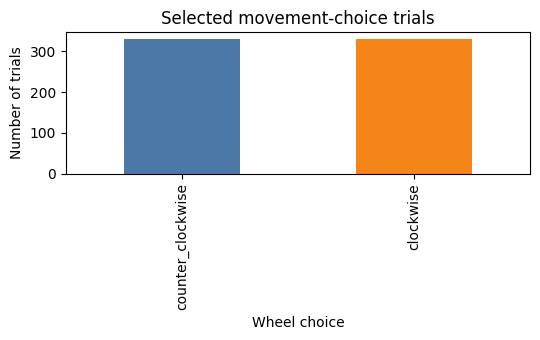

INFO: Saved /content/bwm_colab_outputs/selected_trial_counts.png


In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
choice_counts.plot.bar(x='choice', y='n_trials', ax=ax, legend=False, color=['#4C78A8', '#F58518'])
ax.set_title('Selected movement-choice trials')
ax.set_xlabel('Wheel choice')
ax.set_ylabel('Number of trials')
fig.tight_layout()
trial_plot_path = CONFIG.output_dir / 'selected_trial_counts.png'
fig.savefig(trial_plot_path, dpi=160)
plt.show()
logging.info('Saved %s', trial_plot_path)

## Single-cell analysis: choice modulation before movement onset

For each unit, we count spikes in a short pre-movement window and compare mean firing rates between counter-clockwise and clockwise choices.

### Choice Modulation Index Formula

For each unit, the notebook compares the mean firing rate on counter-clockwise (CCW) and clockwise (CW) trials in the pre-movement count window.

$$
\mathrm{CMI} =
\frac{r_{\mathrm{CCW}} - r_{\mathrm{CW}}}
     {r_{\mathrm{CCW}} + r_{\mathrm{CW}} + \epsilon}
$$

Plain-text version:

```text
CMI = (r_CCW - r_CW) / (r_CCW + r_CW + epsilon)
```

Here, `r_CCW` is the unit's mean firing rate on CCW trials, `r_CW` is the unit's mean firing rate on CW trials, and `epsilon` is a very small number that prevents division by zero.

Interpretation: values near `+1` mean stronger firing on CCW trials, values near `-1` mean stronger firing on CW trials, and values near `0` mean similar firing for the two choices. The shuffle p-value then asks whether this observed index is larger than expected if the choice labels were randomly reassigned.

In [ ]:
def count_spikes_in_event_windows(
    spike_times_by_unit: list[np.ndarray],
    events: np.ndarray,
    window: tuple[float, float],
) -> np.ndarray:
    """Count spikes for each unit and event in a relative time window."""

    starts = events + window[0]
    stops = events + window[1]
    counts = np.zeros((len(spike_times_by_unit), len(events)), dtype=float)
    for unit_index, spike_times in enumerate(spike_times_by_unit):
        left = np.searchsorted(spike_times, starts, side='left')
        right = np.searchsorted(spike_times, stops, side='left')
        counts[unit_index, :] = right - left
    return counts


def run_single_cell_choice_modulation(
    counts: np.ndarray,
    choice: np.ndarray,
    window: tuple[float, float],
    n_shuffles: int,
    random_seed: int,
) -> pd.DataFrame:
    """Compute choice modulation index and a shuffle p-value for each unit."""

    duration = window[1] - window[0]
    rates = counts / duration
    left_mask = choice == -1
    right_mask = choice == 1
    epsilon = 1e-9
    left_mean = rates[:, left_mask].mean(axis=1)
    right_mean = rates[:, right_mask].mean(axis=1)
    modulation = (left_mean - right_mean) / (left_mean + right_mean + epsilon)

    rng = np.random.default_rng(random_seed)
    null = np.zeros((n_shuffles, counts.shape[0]), dtype=float)
    for shuffle_index in range(n_shuffles):
        shuffled_choice = rng.permutation(choice)
        shuffled_left = shuffled_choice == -1
        shuffled_right = shuffled_choice == 1
        shuffled_left_mean = rates[:, shuffled_left].mean(axis=1)
        shuffled_right_mean = rates[:, shuffled_right].mean(axis=1)
        null[shuffle_index, :] = (
            shuffled_left_mean - shuffled_right_mean
        ) / (shuffled_left_mean + shuffled_right_mean + epsilon)

    p_values = (np.sum(np.abs(null) >= np.abs(modulation), axis=0) + 1) / (n_shuffles + 1)
    return pd.DataFrame(
        {
            'unit_index': np.arange(counts.shape[0]),
            'unit_name': [unit.unit_name for unit in analysis_data.units],
            'probe_name': [unit.probe_name for unit in analysis_data.units],
            'left_rate_hz': left_mean,
            'right_rate_hz': right_mean,
            'modulation_index': modulation,
            'p_value_shuffle': p_values,
        }
    )


counts = count_spikes_in_event_windows(
    analysis_data.spike_times_by_unit,
    analysis_data.events,
    CONFIG.count_window,
)

# Make the spike-count matrix visible for teaching the shuffle procedure.
# Rows are trials, columns are selected units, and the counts stay fixed while
# the choice labels are shuffled in the null model.
count_columns = [f'unit_{index:03d}_spike_count' for index in range(counts.shape[0])]
counts_df = pd.DataFrame(counts.T.astype(int), columns=count_columns)
counts_df.insert(0, 'choice_label', analysis_data.trials['mouse_wheel_choice'].astype(str).to_numpy())
counts_df.insert(0, 'choice_numeric', analysis_data.choice)
counts_df.insert(0, 'movement_onset_time_s', analysis_data.events)
counts_df.insert(0, 'trial_index', np.arange(len(analysis_data.trials)))

shuffle_demo_df = counts_df.copy()
shuffle_demo_df.insert(
    4,
    'example_shuffled_choice_label',
    counts_df['choice_label'].sample(frac=1, random_state=CONFIG.random_seed).to_numpy(),
)

logging.info('Spike-count dataframe shape: %s rows x %s columns', *counts_df.shape)
logging.info('The example_shuffled_choice_label column is for visualization only; the analysis shuffles labels internally.')
display(shuffle_demo_df.head(12))

single_cell_df = run_single_cell_choice_modulation(
    counts,
    analysis_data.choice,
    window=CONFIG.count_window,
    n_shuffles=CONFIG.n_shuffles,
    random_seed=CONFIG.random_seed,
)

logging.info('Single-cell choice modulation result head')
display(single_cell_df.head())
logging.info('Single-cell choice modulation summary')
display(single_cell_df[['modulation_index', 'p_value_shuffle']].describe())

INFO: Spike-count dataframe shape: 660 rows x 62 columns
INFO: The example_shuffled_choice_label column is for visualization only; the analysis shuffles labels internally.


,trial_index,movement_onset_time_s,choice_numeric,choice_label,example_shuffled_choice_label,unit_000_spike_count,unit_001_spike_count,unit_002_spike_count,unit_003_spike_count,unit_004_spike_count,...,unit_048_spike_count,unit_049_spike_count,unit_050_spike_count,unit_051_spike_count,unit_052_spike_count,unit_053_spike_count,unit_054_spike_count,unit_055_spike_count,unit_056_spike_count,unit_057_spike_count
0,0,113.477967,-1,counter_clockwise,counter_clockwise,10,5,6,3,6,...,0,1,3,0,0,0,0,0,2,0
1,1,121.328967,-1,counter_clockwise,counter_clockwise,8,3,4,5,4,...,0,0,1,0,0,0,0,0,1,4
2,2,128.465967,1,clockwise,clockwise,5,2,5,2,2,...,0,0,0,0,0,0,0,0,0,0
3,3,132.234967,-1,counter_clockwise,clockwise,4,3,2,6,3,...,0,0,0,0,0,0,0,0,1,0
4,4,139.544967,-1,counter_clockwise,counter_clockwise,5,0,6,5,0,...,0,0,1,0,1,0,1,0,2,0
5,5,143.055967,1,clockwise,counter_clockwise,6,3,3,3,4,...,0,0,0,1,0,0,0,0,1,0
6,6,149.246967,1,clockwise,counter_clockwise,5,2,5,3,0,...,0,1,0,0,0,0,0,0,3,0
7,7,158.768967,1,clockwise,counter_clockwise,2,2,3,3,1,...,0,1,0,1,0,0,0,0,1,0
8,8,168.691967,-1,counter_clockwise,clockwise,8,1,4,2,2,...,0,0,0,1,0,0,0,0,1,0
9,9,176.855967,1,clockwise,clockwise,7,0,5,5,1,...,0,0,0,0,0,0,0,0,1,0


INFO: Single-cell choice modulation result head


,unit_index,unit_name,probe_name,left_rate_hz,right_rate_hz,modulation_index,p_value_shuffle
0,0,probe00_467,Probe00,30.909091,29.313131,0.026501,0.163836
1,1,probe00_300,Probe00,31.030303,25.252525,0.102656,0.001998
2,2,probe00_233,Probe00,27.959596,28.141414,-0.003241,0.855145
3,3,probe00_565,Probe00,24.141414,27.636364,-0.067499,0.002997
4,4,probe00_271,Probe00,30.686869,26.585859,0.071605,0.009990


INFO: Single-cell choice modulation summary


,modulation_index,p_value_shuffle
count,58.000000,58.000000
mean,0.048529,0.404664
std,0.135196,0.369096
min,-0.309091,0.000999
25%,-0.013332,0.040460
50%,0.012408,0.337662
75%,0.100905,0.796953
max,0.411765,0.996004


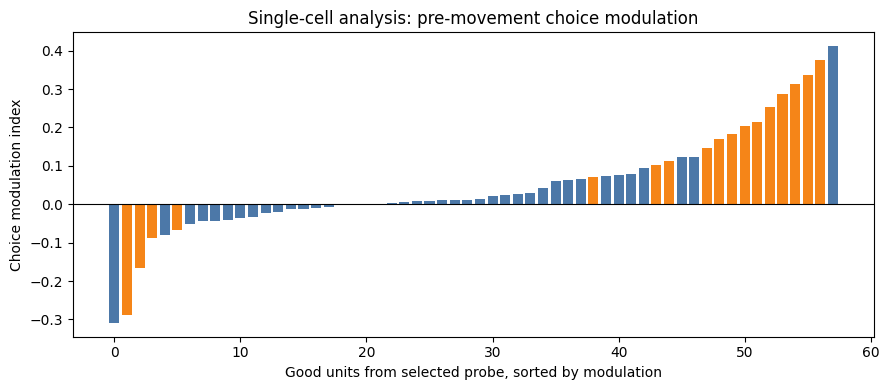

INFO: Saved /content/bwm_colab_outputs/single_cell_choice_modulation.png


In [ ]:
ordered_single_cell = single_cell_df.sort_values('modulation_index').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 4))
colors = np.where(ordered_single_cell['p_value_shuffle'] < 0.05, '#F58518', '#4C78A8')
ax.bar(np.arange(len(ordered_single_cell)), ordered_single_cell['modulation_index'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Good units from selected probe, sorted by modulation')
ax.set_ylabel('Choice modulation index')
ax.set_title('Single-cell analysis: pre-movement choice modulation')
fig.tight_layout()
single_cell_plot_path = CONFIG.output_dir / 'single_cell_choice_modulation.png'
fig.savefig(single_cell_plot_path, dpi=160)
plt.show()
logging.info('Saved %s', single_cell_plot_path)

# Extreme bars are not significant, because they have very low firing rate, and the denominator of modulation is very small.

## Decoding: predict choice from population spike counts

This uses the same pre-movement spike-count matrix, with trials as rows and units as features.

INFO: Decoding metrics


,accuracy,balanced_accuracy,n_train,n_test,n_units,n_trials
0,0.606061,0.606061,330,330,58,660


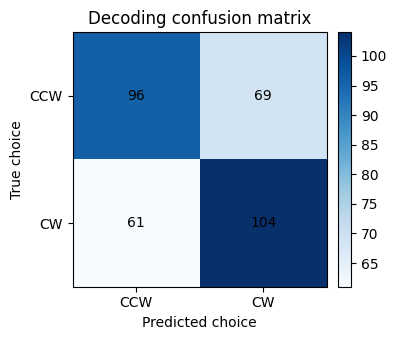

INFO: Saved /content/bwm_colab_outputs/decoding_confusion_matrix.png


In [ ]:
def run_decoding(counts: np.ndarray, choice: np.ndarray, random_seed: int) -> tuple[pd.DataFrame, np.ndarray]:
    """Decode trial choice from selected-unit pre-movement spike counts."""

    x = counts.T
    y = choice
    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.5,
        random_state=random_seed,
        stratify=y,
    )
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(random_state=random_seed, max_iter=1000),
    )
    model.fit(x_train, y_train)
    predicted = model.predict(x_test)
    metrics = pd.DataFrame(
        [
            {
                'accuracy': float(accuracy_score(y_test, predicted)),
                'balanced_accuracy': float(balanced_accuracy_score(y_test, predicted)),
                'n_train': int(len(y_train)),
                'n_test': int(len(y_test)),
                'n_units': int(x.shape[1]),
                'n_trials': int(x.shape[0]),
            }
        ]
    )
    return metrics, confusion_matrix(y_test, predicted, labels=[-1, 1])


decoding_df, confusion = run_decoding(counts, analysis_data.choice, CONFIG.random_seed)
logging.info('Decoding metrics')
display(decoding_df)

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(confusion, cmap='Blues')
ax.set_xticks([0, 1], labels=['CCW', 'CW'])
ax.set_yticks([0, 1], labels=['CCW', 'CW'])
ax.set_xlabel('Predicted choice')
ax.set_ylabel('True choice')
ax.set_title('Decoding confusion matrix')
for row in range(confusion.shape[0]):
    for col in range(confusion.shape[1]):
        ax.text(col, row, str(confusion[row, col]), ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
decoding_plot_path = CONFIG.output_dir / 'decoding_confusion_matrix.png'
fig.savefig(decoding_plot_path, dpi=160)
plt.show()
logging.info('Saved %s', decoding_plot_path)

## Manifold analysis: choice-split population trajectories

We compute per-choice PSTHs for each unit around movement onset, then run PCA on the population activity trajectories.

INFO: PCA input matrix shape


,rows,columns,row_meaning,column_meaning
0,36,58,choice condition x time bin,selected good units


INFO: PCA input matrix used by PCA


probe00_467  probe00_300  probe00_233  \
choice_condition time_from_movement_s                                          
CCW              -0.29                   30.606061    31.666667    31.818182   
                 -0.27                   28.636364    32.272727    28.030303   
                 -0.25                   28.787879    28.787879    28.484848   
                 -0.23                   30.454545    25.606061    27.575758   
                 -0.21                   32.121212    25.606061    26.060606   
                 -0.19                   26.515152    29.242424    33.181818   
                 -0.17                   28.181818    31.363636    25.909091   
                 -0.15                   32.272727    28.333333    29.696970   
                 -0.13                   31.212121    31.818182    27.878788   
                 -0.11                   29.848485    32.424242    30.000000   
                 -0.09                   30.606061    32.424242    30.000000   
                 -0.07                   30.909091    31.515152    27.878788   
                 -0.05                   33.333333    31.666667    26.060606   
                 -0.03                   28.939394    28.181818    27.575758   
                 -0.01                   30.909091    31.212121    25.757576   
                  0.01                   30.151515    29.545455    25.909091   
                  0.03                   33.939394    28.333333    23.939394   
                  0.05                   14.242424    15.000000    12.878788   
CW               -0.29                   30.303030    27.424242    27.878788   
                 -0.27                   30.909091    27.575758    27.727273   
                 -0.25                   31.818182    27.727273    31.060606   
                 -0.23                   29.393939    24.545455    29.848485   
                 -0.21                   35.000000    25.757576    30.606061   
                 -0.19                   28.333333    25.000000    31.666667   
                 -0.17                   31.060606    23.787879    28.484848   
                 -0.15                   31.212121    28.181818    31.515152   
                 -0.13                   26.666667    25.000000    27.575758   
                 -0.11                   28.030303    23.181818    29.242424   
                 -0.09                   32.121212    26.969697    28.030303   
                 -0.07                   29.545455    23.939394    31.060606   
                 -0.05                   32.121212    25.151515    29.848485   
                 -0.03                   27.424242    26.363636    26.515152   
                 -0.01                   27.878788    24.242424    23.181818   
                  0.01                   30.909091    24.696970    24.848485   
                  0.03                   31.212121    27.575758    26.818182   
                  0.05                   14.393939    14.545455    12.727273   

                                       probe00_565  probe00_271  probe00_569  \
choice_condition time_from_movement_s                                          
CCW              -0.29                   32.727273    30.151515    28.181818   
                 -0.27                   32.575758    29.393939    28.333333   
                 -0.25                   34.242424    27.878788    27.878788   
                 -0.23                   30.909091    23.939394    27.727273   
                 -0.21                   29.090909    22.727273    26.969697   
                 -0.19                   30.303030    26.818182    26.060606   
                 -0.17                   29.545455    29.696970    26.060606   
                 -0.15                   27.272727    30.303030    22.272727   
                 -0.13                   26.666667    29.090909    21.363636   
                 -0.11                   26.666667    33.333333    25.454545   
                 -0.09                

INFO: Choice-split PSTH histogram


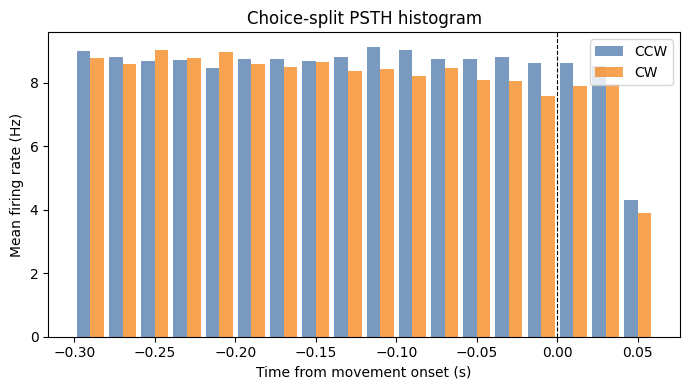

INFO: Saved /content/bwm_colab_outputs/choice_split_psth_histogram.png
INFO: Choice-split population PSTH head


,time_from_movement_s,counter_clockwise_rate_hz,clockwise_rate_hz
0,-0.29,9.009927,8.785266
1,-0.27,8.808777,8.573668
2,-0.25,8.696447,9.033438
3,-0.23,8.717346,8.769592
4,-0.21,8.450888,8.957680


INFO: Manifold distance head


,time_from_movement_s,choice_distance
0,-0.29,8.244047
1,-0.27,5.167685
2,-0.25,8.299851
3,-0.23,6.537182
4,-0.21,11.963074


INFO: Explained variance ratio: [0.59746901 0.22791856]


In [ ]:
def compute_choice_psth(
    spike_times_by_unit: list[np.ndarray],
    events: np.ndarray,
    choice: np.ndarray,
    window: tuple[float, float],
    bin_size: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute choice-split PSTHs for each selected unit."""

    bins = np.arange(window[0], window[1] + bin_size, bin_size)
    centers = bins[:-1] + bin_size / 2.0
    psth = np.zeros((2, len(spike_times_by_unit), len(centers)), dtype=float)
    for condition_index, choice_value in enumerate([-1, 1]):
        condition_events = events[choice == choice_value]
        for unit_index, spike_times in enumerate(spike_times_by_unit):
            hist = np.zeros(len(centers), dtype=float)
            for event in condition_events:
                start = event + window[0]
                stop = event + window[1]
                subset = spike_times[
                    np.searchsorted(spike_times, start, side='left'):
                    np.searchsorted(spike_times, stop, side='left')
                ]
                hist += np.histogram(subset - event, bins=bins)[0]
            psth[condition_index, unit_index, :] = hist / max(len(condition_events), 1) / bin_size
    return psth, centers


def run_manifold(psth: np.ndarray) -> dict[str, Any]:
    """Run PCA on choice-split PSTHs and compute trajectory distance."""

    _, _, n_bins = psth.shape
    matrix = np.vstack([psth[0].T, psth[1].T])
    n_components = min(2, matrix.shape[0], matrix.shape[1])
    pca = PCA(n_components=n_components)
    projected = pca.fit_transform(matrix)
    traj_left = projected[:n_bins]
    traj_right = projected[n_bins:]
    distance = np.linalg.norm(traj_left - traj_right, axis=1)
    return {
        'pca_input_matrix': matrix,
        'pca': pca,
        'traj_left': traj_left,
        'traj_right': traj_right,
        'distance': distance,
    }


psth, time_bins = compute_choice_psth(
    analysis_data.spike_times_by_unit,
    analysis_data.events,
    analysis_data.choice,
    window=CONFIG.psth_window,
    bin_size=CONFIG.psth_bin_size,
)
manifold = run_manifold(psth)
pca_input_matrix = manifold['pca_input_matrix']
pca_input_row_index = pd.MultiIndex.from_product(
    [['CCW', 'CW'], np.round(time_bins, 3)],
    names=['choice_condition', 'time_from_movement_s'],
)
pca_input_df = pd.DataFrame(
    pca_input_matrix,
    index=pca_input_row_index,
    columns=[unit.unit_name for unit in analysis_data.units],
)
pca_input_shape_df = pd.DataFrame(
    [
        {
            'rows': pca_input_matrix.shape[0],
            'columns': pca_input_matrix.shape[1],
            'row_meaning': 'choice condition x time bin',
            'column_meaning': 'selected good units',
        }
    ]
)
manifold_distance_df = pd.DataFrame(
    {
        'time_from_movement_s': time_bins,
        'choice_distance': manifold['distance'],
    }
)
population_psth = psth.mean(axis=1)
population_psth_df = pd.DataFrame(
    {
        'time_from_movement_s': time_bins,
        'counter_clockwise_rate_hz': population_psth[0],
        'clockwise_rate_hz': population_psth[1],
    }
)

logging.info('PCA input matrix shape')
display(pca_input_shape_df)
logging.info('PCA input matrix used by PCA')
display(pca_input_df)
logging.info('Choice-split PSTH histogram')
fig, ax = plt.subplots(figsize=(7, 4))
bar_width = CONFIG.psth_bin_size * 0.42
ax.bar(
    time_bins - bar_width / 2,
    population_psth[0],
    width=bar_width,
    alpha=0.75,
    label='CCW',
    color='#4C78A8',
)
ax.bar(
    time_bins + bar_width / 2,
    population_psth[1],
    width=bar_width,
    alpha=0.75,
    label='CW',
    color='#F58518',
)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Time from movement onset (s)')
ax.set_ylabel('Mean firing rate (Hz)')
ax.set_title('Choice-split PSTH histogram')
ax.legend()
fig.tight_layout()
psth_plot_path = CONFIG.output_dir / 'choice_split_psth_histogram.png'
fig.savefig(psth_plot_path, dpi=160)
plt.show()
logging.info('Saved %s', psth_plot_path)
logging.info('Choice-split population PSTH head')
display(population_psth_df.head())
logging.info('Manifold distance head')
display(manifold_distance_df.head())
logging.info('Explained variance ratio: %s', manifold['pca'].explained_variance_ratio_)

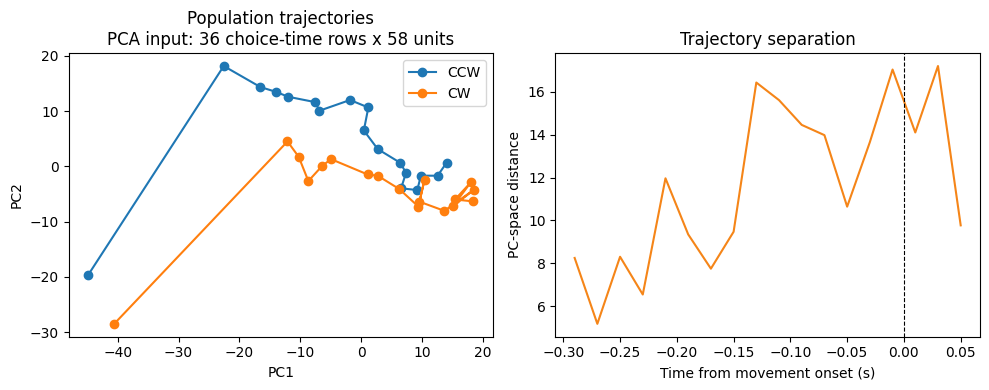

INFO: Saved /content/bwm_colab_outputs/manifold_pca_choice.png


In [ ]:
traj_left = manifold['traj_left']
traj_right = manifold['traj_right']
distance = manifold['distance']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pca_input_shape_text = (
    f'PCA input: {pca_input_matrix.shape[0]} choice-time rows x '
    f'{pca_input_matrix.shape[1]} units'
)

if traj_left.shape[1] == 1:
    axes[0].plot(time_bins, traj_left[:, 0], label='CCW')
    axes[0].plot(time_bins, traj_right[:, 0], label='CW')
    axes[0].set_xlabel('Time from movement onset (s)')
    axes[0].set_ylabel('PC1')
else:
    axes[0].plot(traj_left[:, 0], traj_left[:, 1], marker='o', label='CCW')
    axes[0].plot(traj_right[:, 0], traj_right[:, 1], marker='o', label='CW')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].set_title('Population trajectories\n' + pca_input_shape_text)

axes[1].plot(time_bins, distance, color='#F58518')
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Time from movement onset (s)')
axes[1].set_ylabel('PC-space distance')
axes[1].set_title('Trajectory separation')
fig.tight_layout()
manifold_plot_path = CONFIG.output_dir / 'manifold_pca_choice.png'
fig.savefig(manifold_plot_path, dpi=160)
plt.show()
logging.info('Saved %s', manifold_plot_path)

## Save outputs

The notebook saves CSV summaries and PNG figures. In Colab these will appear under `/content/bwm_colab_outputs` unless you change `BWM_OUTPUT_DIR`.

In [ ]:
analysis_data.trials.to_csv(CONFIG.output_dir / 'selected_trials.csv', index=False)
unit_table.to_csv(CONFIG.output_dir / 'selected_units.csv', index=False)
counts_df.to_csv(CONFIG.output_dir / 'spike_counts_by_trial.csv', index=False)
single_cell_df.to_csv(CONFIG.output_dir / 'single_cell_choice_modulation.csv', index=False)
decoding_df.to_csv(CONFIG.output_dir / 'decoding_accuracy.csv', index=False)
population_psth_df.to_csv(CONFIG.output_dir / 'manifold_choice_psth.csv', index=False)
manifold_distance_df.to_csv(CONFIG.output_dir / 'manifold_distance.csv', index=False)

summary = pd.DataFrame(
    [
        {
            'subject_id': subject_id,
            'session_id': session_id,
            'asset_path': CONFIG.asset_path,
            'data_source': 'dandi_remote',
            'n_trials': len(analysis_data.trials),
            'n_units': len(analysis_data.units),
            'n_shuffles': CONFIG.n_shuffles,
            'decoding_balanced_accuracy': decoding_df.loc[0, 'balanced_accuracy'],
            'max_abs_single_cell_modulation_index': single_cell_df['modulation_index'].abs().max(),
            'elapsed_seconds': time.perf_counter() - start_time,
        }
    ]
)
summary.to_csv(CONFIG.output_dir / 'run_summary.csv', index=False)

logging.info('Run summary')
display(summary)
logging.info('Output files')
display(pd.DataFrame({'path': sorted(str(path) for path in CONFIG.output_dir.glob('*'))}))

close_h5_handles()

INFO: Run summary


,subject_id,session_id,asset_path,data_source,n_trials,n_units,n_shuffles,decoding_balanced_accuracy,max_abs_single_cell_modulation_index,elapsed_seconds
0,KS091,78b4fff5-c5ec-44d9-b5f9-d59493063f00,sub-KS091/sub-KS091_ses-78b4fff5-c5ec-44d9-b5f...,dandi_remote,660,58,1000,0.606061,0.411765,32.400505


INFO: Output files


,path
0,/content/bwm_colab_outputs/choice_split_psth_h...
1,/content/bwm_colab_outputs/decoding_accuracy.csv
2,/content/bwm_colab_outputs/decoding_confusion_...
3,/content/bwm_colab_outputs/manifold_choice_pst...
4,/content/bwm_colab_outputs/manifold_distance.csv
5,/content/bwm_colab_outputs/manifold_pca_choice...
6,/content/bwm_colab_outputs/run_summary.csv
7,/content/bwm_colab_outputs/selected_trial_coun...
8,/content/bwm_colab_outputs/selected_trials.csv
9,/content/bwm_colab_outputs/selected_units.csv
